# 2D rotational Brownian motion: angle PDFs — LAMMPS vs analytical formulas

This notebook compares **single-step PDFs** (probability density functions) computed with LAMMPS using the conventional **Euler+projection method** and a novel **geometric integrator** against **analytical results** for **two-dimensional (2D)** torque-free rotational Brownian motion (RBM) on the unit **circle** (2D RBM; orientation space $S^1$).

The one-step PDF $p(\vartheta;\Delta t)$ depends on the relative angle $\vartheta\in[0,\pi]$ and, for free rotational diffusion, on the dimensionless product $D_R\Delta t$, that is, not on $D_R$ and $\Delta t$ separately, where $D_R$ is the rotational diffusion constant and $\Delta t$ the timestep. Let $\mathbf{u}(t)$ denote the particle’s unit orientation at time $t$. The single-step relative angle is $\vartheta=\arccos(\mathbf{u}(t+\Delta t)\cdot\mathbf{u}(t))$, that is, the rotation angle accumulated during one timestep $\Delta t$. Owing to stationarity of rotational Brownian motion, this single-step distribution is identical to the distribution of the angle between $\mathbf{u}(t)$ and $\mathbf{u}(0)$ at time $t=\Delta t$. In 2D, the angle $\vartheta$ also equals the minimal angular separation between $\varphi(t)$ and $\varphi(t+\Delta t)$ on the circle, i.e. $\vartheta=\min_{k\in\mathbb{Z}}|\varphi(t+\Delta t)-\varphi(t)+2\pi k|\in[0,\pi]$.

**Technical details**, the main **analytical formulas** and **key observations** are summarized below.

### Technical details

We load precomputed `.dat` files for PDFs from:

- LAMMPS numerics (markers): `data/pdf_lammps_circle_{projection,geometric}_Dr<Dr>_dt<dt>.dat`
- Theory (lines): `data/pdf_theory_circle_{exact,projection,geometric}_Dr<Dr>_dt<dt>.dat`

created by:

- `scripts/compute_pdf_from_angles.py` (LAMMPS numerics)
- `scripts/compute_pdf_from_theory.py` (theory)

Since the theory depends on the product $D_R\Delta t$, we fix $D_R$ and vary the timestep $\Delta t$ in the numerical comparisons; thus smaller (larger) timestep below refers to smaller (larger) values of $D_R\Delta t$.

We plot the rescaled angle $x=\vartheta/\pi$ on the horizontal axis and the one-step PDF $p(\vartheta;\Delta t)$ on the vertical axis.  
Notation in code: `theta` $\leftrightarrow \vartheta$, `Dr` $\leftrightarrow D_R$.

## Analytical formulas (2D/circle)

The analytic PDFs below are the corresponding **2D** (circle) counterparts of the **3D** (sphere) one-step PDFs considered in the reference, expressed for the same folded relative angle $\vartheta \in [0,\pi]$.

**Exact:**
$$
  p_{\mathrm{exact}}(\vartheta;\Delta t)=\frac{1}{\pi}\Bigl[ 1+2\sum_{\ell=1}^{\infty}
  \cos(\ell\vartheta){\mathrm e}^{-\ell^2 D_R \Delta t} \Bigr],\qquad 0\le\vartheta\le\pi.
$$

**Geometric scheme:**  
(coincides with the exact PDF; it is convenient to alternatively represent it via a wrapped-Gaussian sum)
$$
  p_{\mathrm{geom}}(\vartheta;\Delta t)=\frac{2}{\sqrt{4\pi D_R\Delta t}}
  \sum_{k\in\mathbb{Z}}\exp\!\left[-\frac{(\vartheta+2\pi k)^2}{4D_R\Delta t}\right].
$$

**Euler + projection scheme:**  
$$
  p_{\mathrm{proj}}(\vartheta;\Delta t)=\frac{2}{\sqrt{4\pi D_R\Delta t}}
  \exp\!\left[-\frac{\tan^2\vartheta}{4D_R\Delta t}\right]\sec^2\vartheta, \quad \text{for } \; 0\le\vartheta<\pi/2
$$
and $p_{\mathrm{proj}}(\vartheta;\Delta t)=0$ for $\vartheta \ge \pi/2$.

In practice we truncate the sums at finite $\ell_\max$ and $k_\max$; see the python script.

**Reference:**  
Felix Höfling & Arthur V. Straube, *Phys. Rev. Research* **7**, 043034 (2025)  
open access, doi:[10.1103/wzdn-29p4](https://doi.org/10.1103/wzdn-29p4)


## Observations

- For sufficiently small timesteps $\Delta t$ (at fixed $D_R$), the PDFs obtained with both the Euler+projection and geometric integrators agree well with the exact analytical one-step PDF over the full range of $\vartheta$.
- The Euler+projection scheme exhibits the characteristic cutoff at $\vartheta=\pi/2$ (finite support), which is in qualitative disagreement with the exact solution.
- As $\Delta t$ is increased, the Euler+projection PDF deviates strongly from the exact solution, whereas the geometric integrator remains qualitatively consistent and quantitatively close to the analytical PDF even at comparatively large timesteps.
  
Recall: for torque-free RBM, the one-step PDF depends only on $D_R\Delta t$; here we fix $D_R$ and vary $\Delta t$ to probe timestep effects.

## Implementation
The following helper functions are shared between the sphere (3D RBM) and circle (2D RBM) notebooks to avoid duplicated code (click to inspect).
- I/O + formatting: [rbm/io.py](../rbm/io.py)
- Plot helper: [rbm/plot.py](../rbm/plot.py)


In [3]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

# --- paths ---
repo_root = Path("..").resolve()
data_dir = repo_root / "data"
figs_dir = repo_root / "figs"
figs_dir.mkdir(exist_ok=True)

# --- allow importing internal helpers from /rbm ---
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from rbm import fmt_float
from rbm.plot import plot_compare_pdf


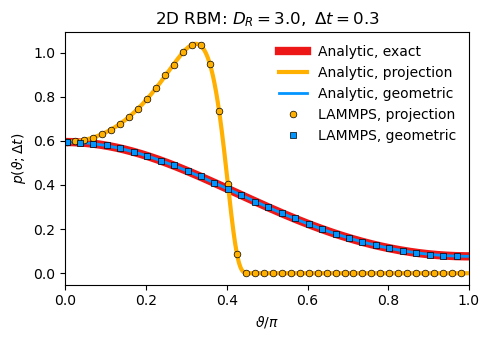

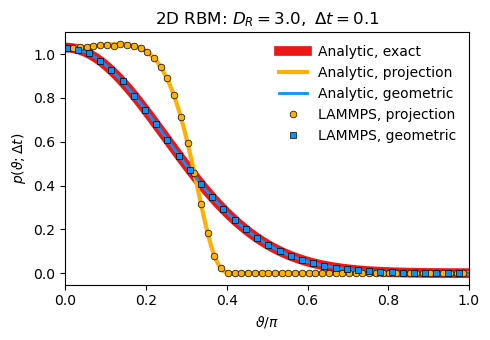

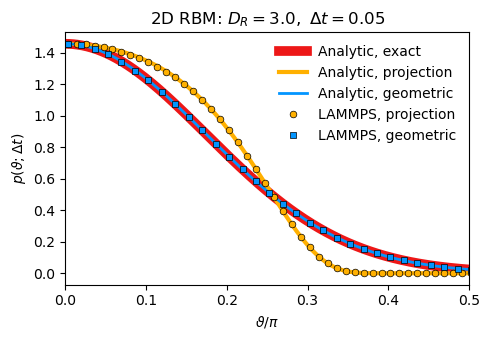

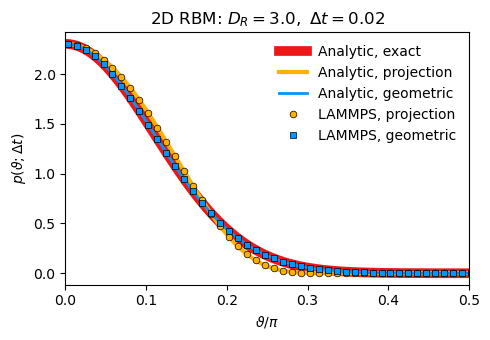

In [4]:
# Make few plots to compare PDFs at different timesteps

manifold = "circle"
Dr = 3.0  # rotational diffusion constant
title_prefix = "2D RBM"

# Per-figure settings (kept from the original notebook)
plot_specs = [
    dict(dt=0.3,  xlim=(0, 1),   step_proj=4, step_geom=6, lw_exact=6.0),
    dict(dt=0.1,  xlim=(0, 1),   step_proj=3, step_geom=5),
    dict(dt=0.05, xlim=(0, 0.5), step_proj=2, step_geom=3),
    dict(dt=0.02, xlim=(0, 0.5), step_proj=2, step_geom=2),
]

for spec in plot_specs:
    dt = spec["dt"]

    fig, ax = plt.subplots(figsize=(5, 3.5))

    plot_compare_pdf(
        ax,
        manifold=manifold,
        data_dir=data_dir,
        Dr=Dr,
        dt=dt,
        **{k: v for k, v in spec.items() if k != "dt"},
    )

    ax.set_title(fr"{title_prefix}: $D_R={fmt_float(Dr)},\ \Delta t={fmt_float(dt)}$")
    fig.tight_layout()

    base = f"compare_pdf_{manifold}_Dr{fmt_float(Dr)}_dt{fmt_float(dt)}"
    fig.savefig(figs_dir / f"{base}.png", dpi=300, bbox_inches="tight")
    fig.savefig(figs_dir / f"{base}.pdf", bbox_inches="tight")

    plt.show()
